In [1]:
!pip install imutils


[notice] A new release of pip available: 22.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import numpy as np 
import cv2
import matplotlib.pyplot as plt
import imutils

In [9]:
img_org = cv2.imread('./images/test2.jpeg')

In [10]:
cv2.namedWindow('original image', cv2.WINDOW_NORMAL)
cv2.imshow('original image', img_org)
cv2.waitKey(0)
cv2.destroyAllWindows()


In [11]:
def resize_func(image, width=590):
    h,w,c = image.shape
    height = int((h/w)* width)
    size= (width,height)
    image = cv2.resize(image,(width,height))
    return image, size
                       
    

In [12]:
img_resize, size = resize_func(img_org)
print(size)
cv2.imshow('test image', img_resize)
cv2.waitKey(0)
cv2.destroyAllWindows()

(590, 885)


In [14]:
hsv = cv2.cvtColor(img_resize, cv2.COLOR_BGR2HSV)
lower_white = np.array([0, 0, 170])
upper_white = np.array([180, 50, 255])
mask = cv2.inRange(hsv, lower_white, upper_white)
kernel_big = np.ones((20, 20), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_big)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_big)

cv2.imshow('mask', mask)
cv2.waitKey(0)
cv2.destroyAllWindows()

contours,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contours = sorted(contours, key=cv2.contourArea, reverse=True)

for contour in contours:
    hull = cv2.convexHull(contour)
    prei = cv2.arcLength(hull, True)
    approx = cv2.approxPolyDP(hull, 0.02 * prei, True)
    if len(approx) == 4:
        four_pts = np.squeeze(approx)
        break

cv2.drawContours(img_resize, [four_pts], -1, (0, 45, 233), 3)
multiplier = img_org.shape[1] / size[0]
four_pts = four_pts * multiplier
four_pts = four_pts.astype(int)

cv2.imshow('detected', img_resize)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [16]:
from imutils.perspective import four_point_transform

In [17]:
img_wrap = four_point_transform(img_org, four_pts)

In [18]:

cv2.imshow('wrap' ,img_wrap)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [19]:
def bill_scanner(image):
    img_resize, size = resize_func(image)
    
    hsv = cv2.cvtColor(img_resize, cv2.COLOR_BGR2HSV)
    lower_white = np.array([0, 0, 170])
    upper_white = np.array([180, 50, 255])
    mask = cv2.inRange(hsv, lower_white, upper_white)
    kernel_big = np.ones((20, 20), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_big)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_big)

    
    contours,_ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    contours = sorted(contours, key=cv2.contourArea, reverse=True)
    
    for contour in contours:
        hull = cv2.convexHull(contour)
        prei = cv2.arcLength(hull, True)
        approx = cv2.approxPolyDP(hull, 0.02 * prei, True)
        if len(approx) == 4:
            four_pts = np.squeeze(approx)
            break
    
    cv2.drawContours(img_resize, [four_pts], -1, (0, 45, 233), 3)
    multiplier = image.shape[1] / size[0]
    four_pts = four_pts * multiplier
    four_pts = four_pts.astype(int)
    
    
    
    img_wrap = four_point_transform(image, four_pts)

    return img_wrap, four_pts, img_resize, mask

In [20]:
img = cv2.imread('./images/test1.jpeg')
wp_img, pts_img, cont_img, msk_img = bill_scanner(img)

In [21]:
cv2.imshow('last3', msk_img)
cv2.imshow('last2', cont_img)
cv2.imshow('last', wp_img)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [22]:
def bright_cont(input_img , brightness = 0, contrast=0):
    if brightness != 0:
        if brightness> 0:
            shadow = brightness
            highlight = 255
        else:
            shadow = 0
            highlight = 255+ brightness
        alpha_b =(highlight - shadow)/ 255
        gamma_b = shadow
        buf = cv2.addWeighted(input_img, alpha_b, input_img, 0, gamma_b)
    else:
        buf = input_img.copy()
    if contrast != 0:
        f =131*(contrast+127)/(127*(131-contrast))
        alpha_c = f
        gamma_c = 127*(1-f)

        buf = cv2.addWeighted(buf, alpha_c, buf, 0, gamma_c)
        
    return buf
                               

In [23]:
rgb_img = cv2.cvtColor(wp_img, cv2.COLOR_BGR2RGB)
fixed_img_1 = bright_cont(rgb_img, 85,0)
fixed_img_2 = bright_cont(rgb_img, 0,35)
fixed_img_3 = bright_cont(rgb_img, 60,35)

True

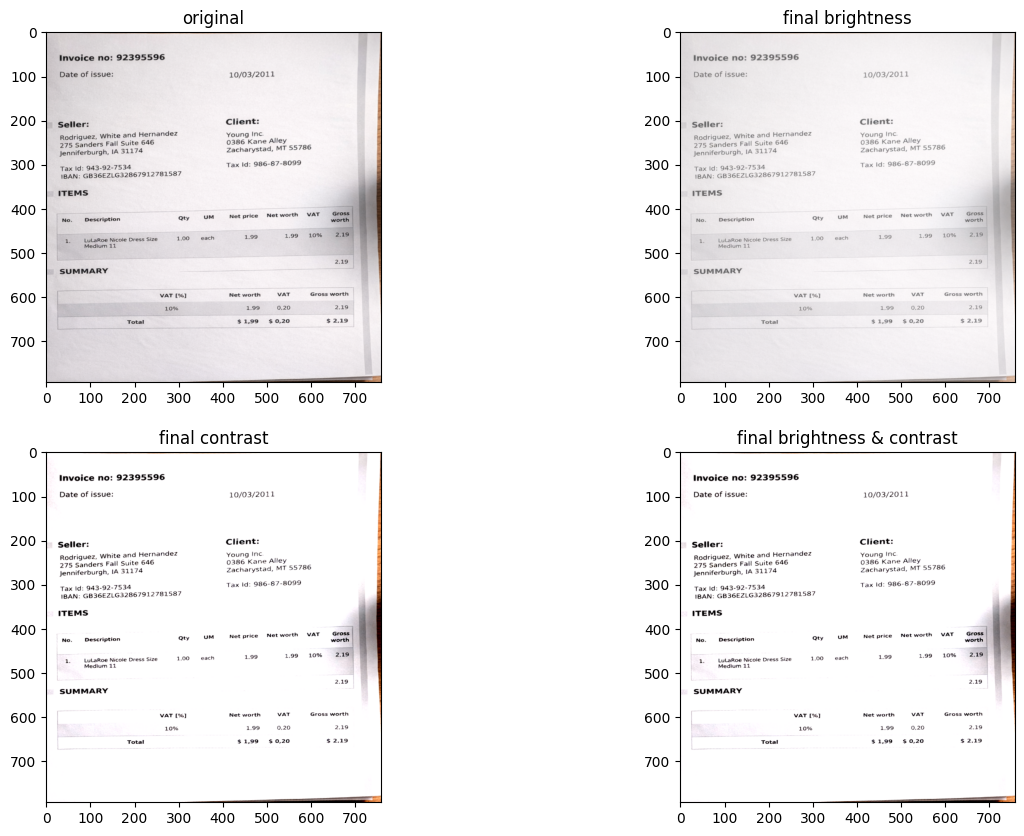

In [24]:
plt.figure(figsize=(15,10))
plt.subplot(2,2,1)
plt.imshow(rgb_img)
plt.title('original')

plt.subplot(2,2,2)
plt.imshow(fixed_img_1)
plt.title('final brightness')

plt.subplot(2,2,3)
plt.imshow(fixed_img_2)
plt.title('final contrast')

plt.subplot(2,2,4)
plt.imshow(fixed_img_2)
plt.title('final brightness & contrast')

plt.show()

In [25]:
import predictions as pred

In [26]:
img_pred, results = pred.get_predictions(fixed_img_3)

Invoice no 92395596 Date of issue Seller Rodriguez, White and Hernandez 275 Sanders Fall Suite 646 Jenniferburgh, IA 31174 Tax Id 943927534 IBAN GB36EZLG3286 7912781587 ITEMS No. Description aty 1. LuLaRoe Nicole Dress Size 1.00 Medium 11, SUMMARY VAT 10. Total um each 10/03/2011 Client Young Inc 0386 Kane Alley Zacharystad, MT 55786 Tax Id 986878099 Net price 1.99 Net worth 1,99 1,99 Net worth 1.99 vat 0.20 0,20 VAT Gross 10 2.19 2.19 Gross worth 2.19 2.19


In [28]:
cv2.namedWindow('Predictions', cv2.WINDOW_NORMAL)
cv2.imshow('Predictions', img_pred)
cv2.waitKey(0)
cv2.destroyAllWindows()

In [29]:
results

{'ID': ['92395596'],
 'DATE': ['10/03/2011'],
 'SN': ['rodriguez white and hernandez'],
 'CN': ['young inc'],
 'IBAN': ['gb36ezlg3286'],
 'TOTAL': ['219']}